In [ ]:
#Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [3]:
#Função que plota as comparações entre valores reais e preditos
def plot_dtc_reg_comparison(df,log_comp='DTC_Linear_Reg'):
    
    fig,axes = plt.subplots(nrows=1, ncols=4, figsize=(9,15))

    y_lim = (np.floor((df.index.min()-100)/50)*50, np.ceil((df.index.max()+1)/50)*50)
    step = 250

    for ax in axes:
        ax.set_yticks(np.arange(y_lim[0], y_lim[1], step))
        ax.set_ylim(y_lim[0], y_lim[1])
        ax.invert_yaxis()
        ax.grid()
        
    axes[0].plot(df.GR,df.index,lw=0.8,color='black',label='GR')
    axes[0].set_xlim(0,150)
    axes[0].set_xlabel('GR (uApi)',fontsize=16)

    axes[0].set_ylabel('Depth (m)',fontsize=16)

    #Adicionando um eixo gêmeo para o caliper
    axes0 = axes[0].twiny()
    axes0.plot(df.CALI,df.index,lw=0.8,color='red',ls='--',label='CALI')
    axes0.set_xlabel('CALI (in)',fontsize=16)
    axes0.set_xlim(6,18)
    axes0.legend(loc='upper left',fontsize=8)
        

    axes[1].semilogx(df.RDEP,df.index,lw=0.8,color='black',label='ILD')
    axes[1].semilogx(df.RMED,df.index,color='red',lw=0.8,ls='--',label='ILM')

    axes[1].set_xlabel(r'$Res$ ($\Omega \cdot m$)',fontsize=16)
    axes[1].set_xlim(1, 1000)
    axes[1].set_xticks([1,10,100,1000])
    axes[1].grid(which='both',axis='x')


    axes[2].plot(df.DTC,df.index,lw=0.8,color='black',label='DT')
    axes[2].set_xlim(140,40)
    axes[2].set_xlabel(r'$\Delta t$ ($\mu$s/ft)',fontsize=16)

    axes[2].plot(df[log_comp],df.index,lw=0.8,color='RED',label='DT',ls='--')


    axes[3].plot(df.RHOB,df.index,lw=0.8,color='black',label='RHOB')
    axes[3].set_xlim(2,3)
    axes[3].set_xlabel(r'g/cm$^3$',fontsize=16)

    fig.tight_layout()
    
    return fig, axes

In [4]:
dataset = pd.read_csv('Dados/train_dataset_proc.csv',index_col=0)
dataset.head()

,WELL,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP,GROUP_num,LITHOLOGY,RMED_log,RDEP_log
4238,15/9-13,1138.704,19.322735,1.013309,1.091499,1.774626,55.892757,0.765867,147.837677,30000,NORDLAND GP.,6,Sandstone (Arenito),0.005742,0.038023
4239,15/9-13,1138.856,18.613674,1.088184,1.122706,1.800986,60.929138,0.800262,142.382431,65000,NORDLAND GP.,6,Shale (Argilito),0.036703,0.050266
4240,15/9-13,1139.008,18.212072,1.127155,1.148141,1.817696,62.117264,0.765957,138.258331,65000,NORDLAND GP.,6,Shale (Argilito),0.051984,0.059995
4241,15/9-13,1139.160,18.134182,1.141467,1.170984,1.829333,61.010860,0.702521,139.198914,65000,NORDLAND GP.,6,Shale (Argilito),0.057463,0.068551
4242,15/9-13,1139.312,18.033762,1.138007,1.184080,1.813854,58.501236,0.639708,144.290085,65000,NORDLAND GP.,6,Shale (Argilito),0.056145,0.073381


In [5]:
blind = pd.read_csv('Dados/blind_dataset_proc.csv',index_col=0)
blind.head()

,WELL,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP,GROUP_num,LITHOLOGY,RMED_log,RDEP_log
611166,34/8-1,1725.769023,18.106157,0.560608,0.438534,2.152554,83.007614,0.559823,137.522156,70000,HORDALAND GP.,5,Limestone (Calcário),-0.251341,-0.357996
611167,34/8-1,1725.921023,18.054070,0.547699,0.443202,2.118826,83.586533,0.523454,143.998734,70000,HORDALAND GP.,5,Limestone (Calcário),-0.261458,-0.353399
611168,34/8-1,1726.073023,18.077368,0.545528,0.451811,2.092709,79.901100,0.501679,147.367950,65000,HORDALAND GP.,5,Shale (Argilito),-0.263183,-0.345043
611169,34/8-1,1726.225023,18.336990,0.553675,0.451893,2.082126,77.101242,0.498488,152.517838,65000,HORDALAND GP.,5,Shale (Argilito),-0.256745,-0.344964
611170,34/8-1,1726.377023,18.467144,0.555517,0.448975,2.068186,75.810783,0.519643,155.653152,65000,HORDALAND GP.,5,Shale (Argilito),-0.255303,-0.347778


In [6]:
dataset.describe()

,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP_num,RMED_log,RDEP_log
count,372745.000000,372745.000000,372745.000000,372745.000000,372745.000000,372745.000000,372745.000000,372745.000000,372745.000000,372745.000000,372745.000000,372745.000000
mean,2620.127037,12.172732,4.747083,4.513840,2.337940,72.871621,0.340219,104.707735,61209.837090,6.408698,0.341259,0.309682
std,922.608418,3.237736,29.099823,34.518880,0.242368,34.647333,0.134809,28.268109,13521.996186,3.184685,0.430379,0.413397
min,414.761016,3.336693,0.095034,0.087607,1.058234,0.898921,-0.035822,7.415132,30000.000000,0.000000,-1.022121,-1.057460
25%,1958.503790,9.078100,1.030169,1.049861,2.165270,50.705021,0.248493,82.467728,65000.000000,3.000000,0.012909,0.021132
50%,2598.108796,12.299666,1.838842,1.716671,2.392286,72.379753,0.339988,97.344543,65000.000000,6.000000,0.264544,0.234687
75%,3253.704000,13.617474,4.168270,3.610907,2.527431,88.864235,0.431681,126.495026,65000.000000,9.000000,0.619956,0.557616
max,4927.276000,25.717396,1988.616333,1999.877808,3.262041,1076.963867,0.999570,320.478882,99000.000000,12.000000,3.298551,3.301003


### Separando treino e teste

In [7]:
#Separando o conjunto em teste e treino

columns = dataset.drop(['LITHOLOGY','GROUP','WELL','DEPTH_MD','DTC'], axis=1).columns

X = dataset[columns]
y = dataset['DTC']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    stratify=dataset['FORCE_2020_LITHOFACIES_LITHOLOGY'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
### Regressão Linear

In [8]:
#Aplicando regressão linear sem normalização

lr = LinearRegression()
lr.fit(X_train, y_train)

print('Log do treino')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_train, lr.predict(X_train)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_train, lr.predict(X_train)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_train, lr.predict(X_train)):.2f}')
print('---'*20)
print('Log do teste')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_test, lr.predict(X_test)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_test, lr.predict(X_test)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_test, lr.predict(X_test)):.2f}')

Log do treino
Erro médio absoluto (MAE): 8.45
Erro quadrático médio (MSE): 143.22
Coeficiente de determinação (R²): 0.82
------------------------------------------------------------
Log do teste
Erro médio absoluto (MAE): 8.45
Erro quadrático médio (MSE): 145.23
Coeficiente de determinação (R²): 0.82


In [9]:
lr.coef_

array([ 5.72271532e-01,  2.61035889e-02,  1.00034221e-02, -5.06454755e+01,
        3.76686173e-02,  7.28293799e+01,  1.04982951e-04, -3.86354859e-01,
       -1.10531730e+01, -1.88961842e+00])

In [10]:
#Normalizando os dados
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Aplicando regressão linear com normalização
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

#Printando métricas
print('Log do treino')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_train, lr.predict(X_train_scaled)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_train, lr.predict(X_train_scaled)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_train, lr.predict(X_train_scaled)):.2f}')

print('---'*20)
print('Log do teste')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_test, lr.predict(X_test_scaled)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_test, lr.predict(X_test_scaled)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_test, lr.predict(X_test_scaled)):.2f}')

Log do treino
Erro médio absoluto (MAE): 8.45
Erro quadrático médio (MSE): 143.22
Coeficiente de determinação (R²): 0.82
------------------------------------------------------------
Log do teste
Erro médio absoluto (MAE): 8.45
Erro quadrático médio (MSE): 145.23
Coeficiente de determinação (R²): 0.82


In [11]:
lr.coef_

array([  1.85344594,   0.7545029 ,   0.34230926, -12.27459153,
         1.30500373,   9.81732041,   1.41957961,  -1.23085973,
        -4.76143102,  -0.78206155])

In [12]:
#Aplicando no blind dataset
blind_scaled = scaler.transform(blind[columns])
blind['DTC_Linear_Reg'] = lr.predict(blind_scaled)

blind.head()

,WELL,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP,GROUP_num,LITHOLOGY,RMED_log,RDEP_log,DTC_Linear_Reg
611166,34/8-1,1725.769023,18.106157,0.560608,0.438534,2.152554,83.007614,0.559823,137.522156,70000,HORDALAND GP.,5,Limestone (Calcário),-0.251341,-0.357996,143.003221
611167,34/8-1,1725.921023,18.054070,0.547699,0.443202,2.118826,83.586533,0.523454,143.998734,70000,HORDALAND GP.,5,Limestone (Calcário),-0.261458,-0.353399,142.157521
611168,34/8-1,1726.073023,18.077368,0.545528,0.451811,2.092709,79.901100,0.501679,147.367950,65000,HORDALAND GP.,5,Shale (Argilito),-0.263183,-0.345043,141.247227
611169,34/8-1,1726.225023,18.336990,0.553675,0.451893,2.082126,77.101242,0.498488,152.517838,65000,HORDALAND GP.,5,Shale (Argilito),-0.256745,-0.344964,141.522862
611170,34/8-1,1726.377023,18.467144,0.555517,0.448975,2.068186,75.810783,0.519643,155.653152,65000,HORDALAND GP.,5,Shale (Argilito),-0.255303,-0.347778,143.784816


(<Figure size 900x1500 with 5 Axes>,
 array([<Axes: xlabel='GR (uApi)', ylabel='Depth (m)'>,
        <Axes: xlabel='$Res$ ($\\Omega \\cdot m$)'>,
        <Axes: xlabel='$\\Delta t$ ($\\mu$s/ft)'>,
        <Axes: xlabel='g/cm$^3$'>], dtype=object))

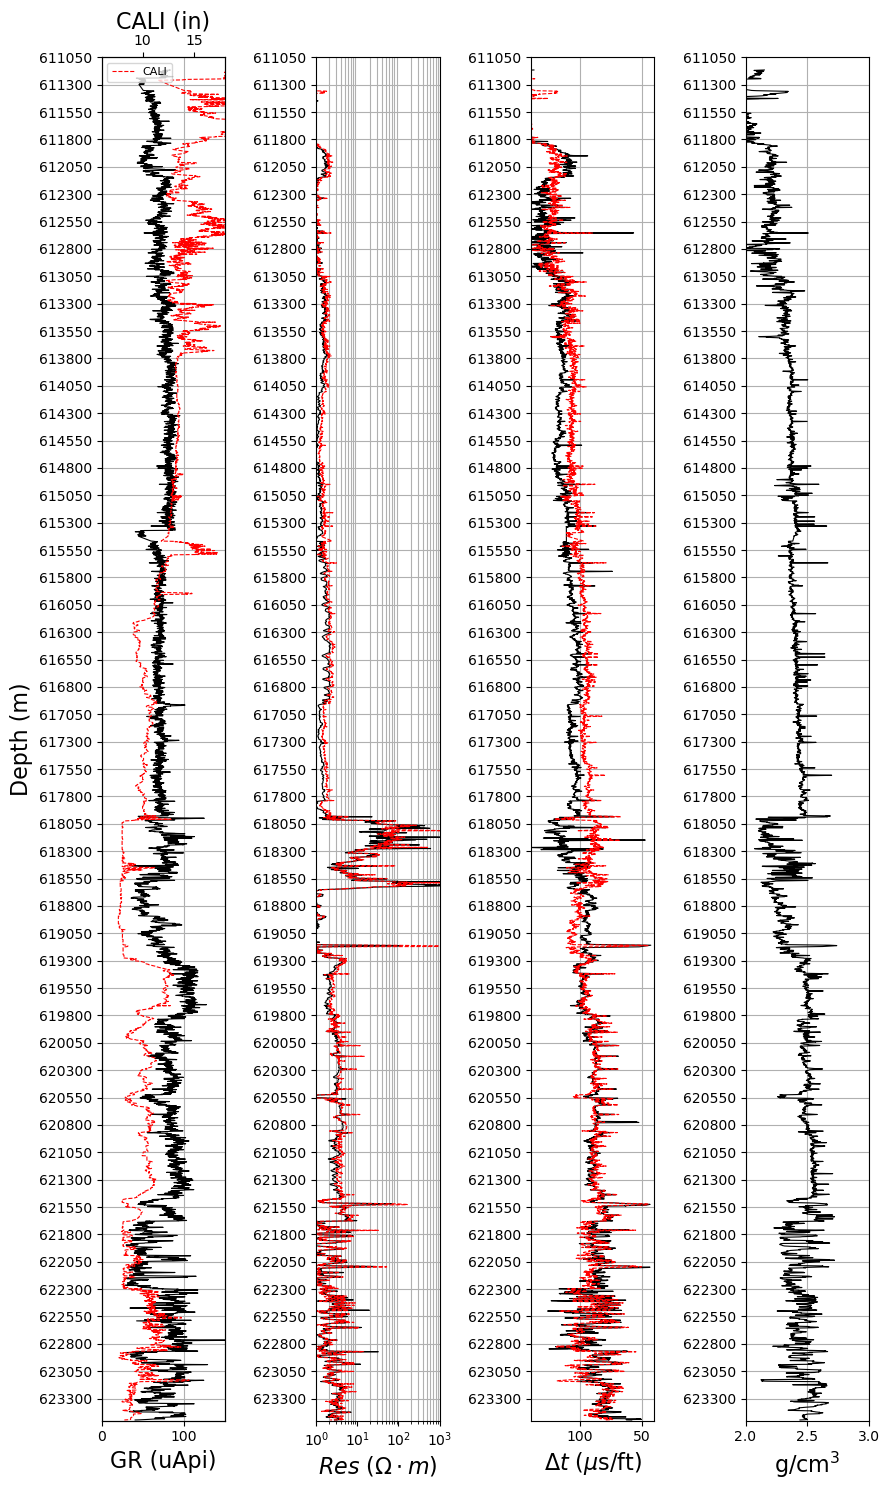

In [13]:
plot_dtc_reg_comparison(blind, log_comp='DTC_Linear_Reg')

In [14]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import make_scorer, mean_absolute_error


mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

scaler= StandardScaler()
X_scaled = scaler.fit(X)
X_scaled = scaler.transform(X)


lr = LinearRegression()


sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select='auto',
    direction='backward',
    scoring=mae_scorer,
    cv=5# <-- Aqui entra o MAE,
)

sfs.fit(X_scaled, y)

best_features = X.columns[sfs.get_support()]

print(best_features)


Index(['RHOB', 'GR', 'NPHI', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'RDEP_log'], dtype='object')


In [15]:
best_features = X.columns[sfs.get_support()]
best_features

Index(['RHOB', 'GR', 'NPHI', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'RDEP_log'], dtype='object')

In [27]:
scaler = StandardScaler()
scaler.fit(X_train[best_features])
X_train_scaled = scaler.transform(X_train[best_features])
X_test_scaled = scaler.transform(X_test[best_features])

lr.fit(X_train_scaled, y_train)


#Printando métricas
print('Log do treino')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_train, lr.predict(X_train_scaled)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_train, lr.predict(X_train_scaled)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_train, lr.predict(X_train_scaled)):.2f}')

print('---'*20)
print('Log do teste')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_test, lr.predict(X_test_scaled)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_test, lr.predict(X_test_scaled)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_test, lr.predict(X_test_scaled)):.2f}')

Log do treino
Erro médio absoluto (MAE): 8.57
Erro quadrático médio (MSE): 149.03
Coeficiente de determinação (R²): 0.81
------------------------------------------------------------
Log do teste
Erro médio absoluto (MAE): 8.58
Erro quadrático médio (MSE): 151.83
Coeficiente de determinação (R²): 0.81


In [32]:
#Analizando o erro por litologia
X_blind_scaled = scaler.transform(blind[best_features])
y_blind = blind['DTC']

print('Log do blind')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_blind, lr.predict(X_blind_scaled)):.2f}')
print(f'Erro quadrático médio (MSE): {mean_squared_error(y_blind, lr.predict(X_blind_scaled)):.2f}')
print(f'Coeficiente de determinação (R²): {r2_score(y_blind, lr.predict(X_blind_scaled)):.2f}')
print('\n'+'---'*20)

print("Erro por litologia:")

for i in blind.LITHOLOGY.unique():
    print(f"Litologia: {i}")
    print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_blind[blind.LITHOLOGY==i], lr.predict(X_blind_scaled[blind.LITHOLOGY==i])):.2f}')

Log do blind
Erro médio absoluto (MAE): 7.59
Erro quadrático médio (MSE): 90.72
Coeficiente de determinação (R²): 0.74

------------------------------------------------------------
Erro por litologia:
Litologia: Limestone (Calcário)
Erro médio absoluto (MAE): 8.50
Litologia: Shale (Argilito)
Erro médio absoluto (MAE): 7.52
Litologia: Tuff (Tufo)
Erro médio absoluto (MAE): 15.19
Litologia: Sandstone (Arenito)
Erro médio absoluto (MAE): 9.59
Litologia: Dolomite (Dolomita)
Erro médio absoluto (MAE): 7.04
Litologia: Sandstone/Shale (Arenito/Argilito)
Erro médio absoluto (MAE): 5.26
